TASK 4: DATA MERGING AND ADVANCED ANALYSIS.

4.1: Ratio of Users to Population by state.

                                   State  Population  Registered Users  \
0              Andaman & Nicobar Islands      380581             62095   
1                         Andhra Pradesh    49378776          19620905   
2                      Arunachal Pradesh     1606047            270572   
3                                  Assam    34461385           3617056   
4                                  Bihar   103817951          14972134   
5                             Chandigarh     1055450            448572   
6                           Chhattisgarh    25867958           4837055   
7   Dadra & Nagar Haveli and Daman & Diu      586956            344994   
8                                  Delhi    16787941          11182699   
9                                    Goa     1457723            609106   
10                               Gujarat    65930328          15735981   
11                               Haryana    25855357          10530594   
12                      Himachal Prade

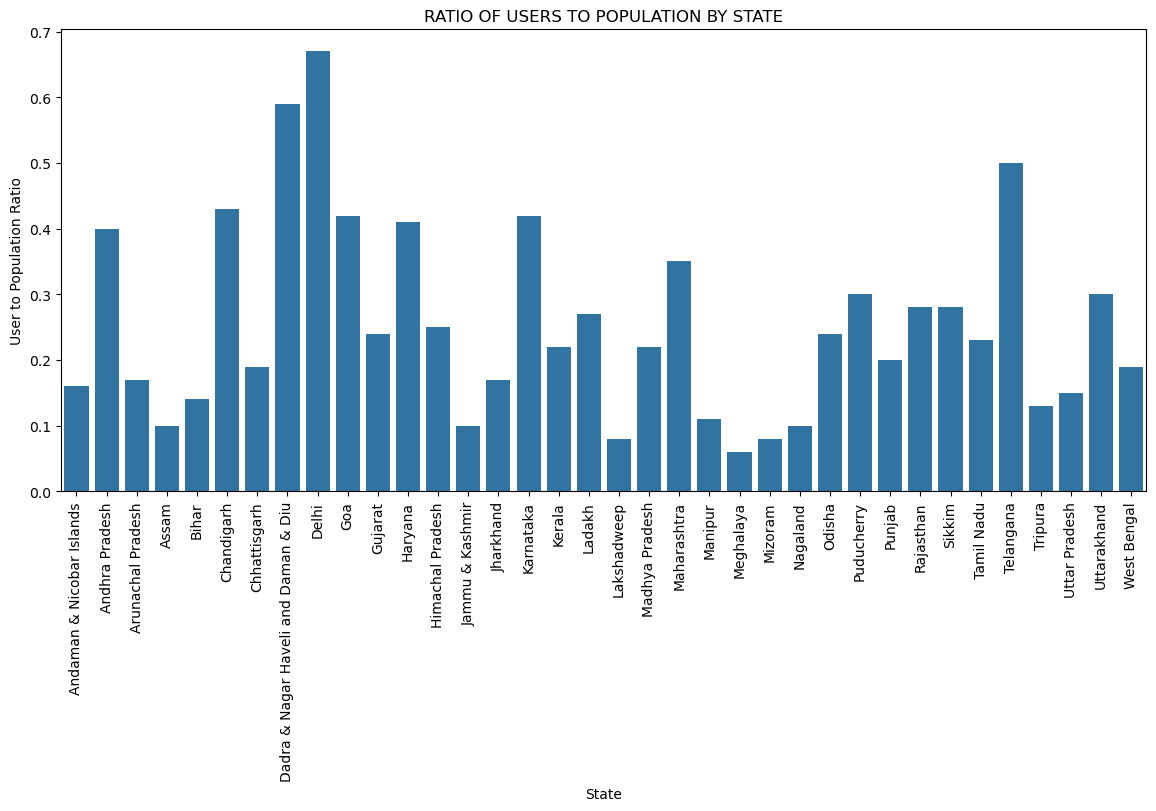

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
s_txnusers=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='State_Txn and Users')
d_demo=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='District Demographics')

# AGGREGATE THE TOTAL POPULATION BY STATE 
res1=d_demo.groupby('State')['Population'].sum().reset_index()

# AGGREGATE THE TOTAL USERS BY STATE
res2=s_txnusers.groupby('State')['Registered Users'].max().reset_index()

# MERGE BOTH DATA

merged=res1.merge(res2,
                  on='State')
merged['Ratio_UtoP']=(merged['Registered Users']/merged['Population']).round(2)
print(merged)

# PLOT A COLUMN CHART
plt.figure(figsize=(14,6))
sns.barplot(data=merged,x='State',y='Ratio_UtoP')
plt.title('RATIO OF USERS TO POPULATION BY STATE')
plt.xlabel('State')
plt.ylabel('User to Population Ratio')
plt.xticks(rotation=90)
plt.show()

INSIGHT--> THE STATE OF DELHI HAS HIGHEST AND THE STATE OF MEGHALAYA HAS LOWEST USER TO POPULATION RATIO.

4.2--> Correlate population density with transaction volume.
   --> Calculate the correlation and create a scatter plot to visualize correlation.

The Correlation between Population Density and Transactions is: 0.048465001743023844.


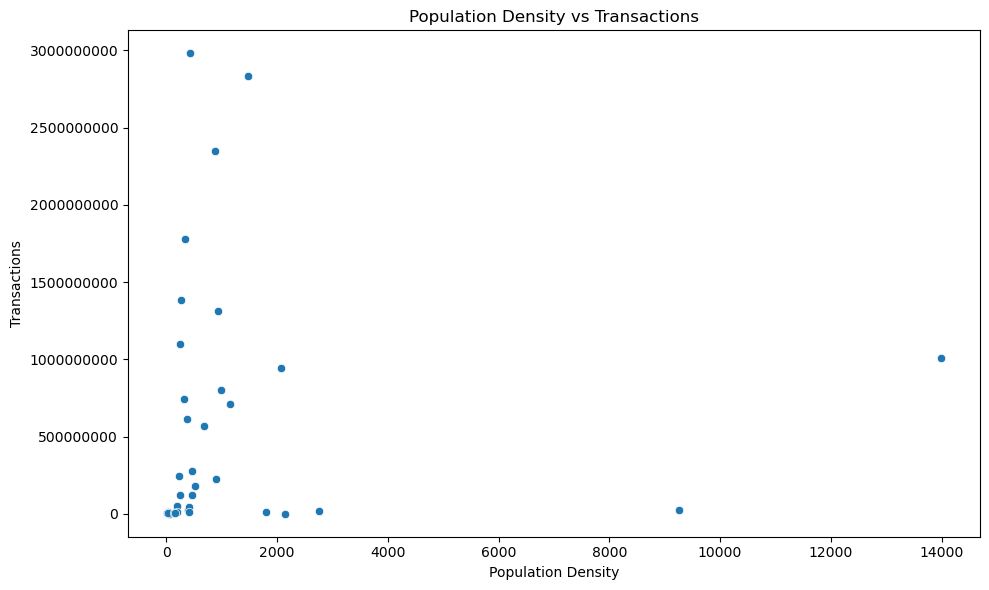

In [17]:
# AGGREGATE THE TOTAL POPULATION DENSITY BY STATE
pdn=d_demo.groupby('State')['Density'].mean().reset_index()

# AGGREGATE THE TRANSACTIONS BY STATE
tst=s_txnusers.groupby('State')['Transactions'].sum().reset_index()

# MERGE BOTH DATASETS
merged=pdn.merge(tst,on='State')

# FIND CORRELATION BETWEEN DENSITY AND TRANSACTIONS
corr=merged['Density'].corr(merged['Transactions'])
print(f"The Correlation between Population Density and Transactions is: {corr}.")

# PLOT SCATTER PLOT
plt.figure(figsize=(10,6))
sns.scatterplot(data=merged,x='Density',y='Transactions')
plt.title('Population Density vs Transactions')
plt.xlabel('Population Density')
plt.ylabel('Transactions')
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.show()

INSIGHT--> The scatter Plot shows very low correlation.

4.3 --> Average Transaction Amount per user for each state.
    -->Identify Top 5  and Bottom 5 ATV per user.

In [40]:
latest_year=s_txnusers['Year'].max()
latest_quarter=s_txnusers[s_txnusers['Year']==latest_year]['Quarter'].max()

# FILTER THE DATA FOR THE LATEST YEAR AND QUARTER
latest_data=s_txnusers[(s_txnusers['Year']==latest_year) & (s_txnusers['Quarter']==latest_quarter)].copy()
latest_data['AvgTV']=(latest_data['Amount (INR)']/latest_data['Registered Users']).round(2)

# AGGREGATE TO GET STATE AND AVERAGE AMOUNT PER USER
result=latest_data.groupby('State')['AvgTV'].sum().round(2).reset_index()
result=result.sort_values(by='AvgTV',ascending=False)

res1=result.head()
res2=result.tail().sort_values(by='AvgTV')
print("The Top 5 Average Transaction Value per User are:")
print(res1)
print("The Bottom 5 Average Transaction Value per User are:")
print(res2)

The Top 5 Average Transaction Value per User are:
             State     AvgTV
31       Telangana  56151.48
1   Andhra Pradesh  43358.73
15       Karnataka  32538.01
28       Rajasthan  29592.92
19  Madhya Pradesh  26692.33
The Bottom 5 Average Transaction Value per User are:
                                   State     AvgTV
18                           Lakshadweep   5593.03
32                               Tripura   7345.40
7   Dadra & Nagar Haveli and Daman & Diu   9152.82
12                      Himachal Pradesh   9463.11
16                                Kerala  10008.90


In [3]:
import pandas as pd
s_txnusers=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='State_Txn and Users')
s_txnusers['AvgTV']=(s_txnusers['Amount (INR)']/s_txnusers['Registered Users']).round(2)

# AGGREGATE TO GET STATE AND AVERAGE AMOUNT PER USER
result=s_txnusers.groupby('State')['AvgTV'].mean().round(2).reset_index()
result=result.sort_values(by='AvgTV',ascending=False)

res1=result.head()
res2=result.tail().sort_values(by='AvgTV')
print("The Top 5 Average Transaction Value per User are:")
print(res1)
print("The Bottom 5 Average Transaction Value per User are:")
print(res2)

The Top 5 Average Transaction Value per User are:
             State     AvgTV
31       Telangana  23774.04
1   Andhra Pradesh  17502.28
15       Karnataka  17318.86
8            Delhi  14791.88
28       Rajasthan  13708.12
The Bottom 5 Average Transaction Value per User are:
                                   State    AvgTV
32                               Tripura  4956.29
18                           Lakshadweep  5492.60
16                                Kerala  6038.02
7   Dadra & Nagar Haveli and Daman & Diu  6168.98
12                      Himachal Pradesh  6373.20


INSIGHT--> IN THE TOP 5 STATES, TELANGANA HAS THE HIGHEST AVERAGE AMOUNT PER USER. WHILE LAKSHADWEEP HAS THE LOWEST.

4.4--> Device Brand Usage Ratio.

-->Calculate the ratio of users using each device brand to the total number of registered users in each state.
--> Create a bar chart depicting the device brand usage ratio for each state.

In [50]:
s_device=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='State_DeviceData')

# TAKE LATEST DATA FOR TOTAL REGISTERED USERS AND DEVICE TYPE USERS
latest_data_device=s_device[(s_device['Year']==latest_year) & (s_device['Quarter']==latest_quarter)]
latest_data_txn=s_txnusers[(s_txnusers['Year']==latest_year) & (s_txnusers['Quarter']==latest_quarter)]

# AGGREGATE
brand_users=latest_data_device.groupby(['State','Brand'])['Registered Users'].sum().reset_index()
total_users=latest_data_txn.groupby('State')['Registered Users'].sum().reset_index()
total_users=total_users.rename(columns={'Registered Users': 'Total_Users'})

# MERGE BOTH THE DATASET
merged=brand_users.merge(total_users,on='State')

# CALCULATE RATIO
merged['ratio']=(merged['Registered Users']/merged['Total_Users'])
merged['user_ratio%']=(merged['ratio']*100).round(2)
print(merged)

                         State     Brand  Registered Users  Total_Users  \
0    Andaman & Nicobar Islands     Apple              1153        62095   
1    Andaman & Nicobar Islands    Huawei              1559        62095   
2    Andaman & Nicobar Islands  Motorola              1054        62095   
3    Andaman & Nicobar Islands   OnePlus              1981        62095   
4    Andaman & Nicobar Islands      Oppo              5456        62095   
..                         ...       ...               ...          ...   
391                West Bengal    Others           1928653     17979979   
392                West Bengal    Realme           1419072     17979979   
393                West Bengal   Samsung           3778434     17979979   
394                West Bengal      Vivo           2703412     17979979   
395                West Bengal    Xiaomi           4654760     17979979   

        ratio  user_ratio%  
0    0.018568         1.86  
1    0.025107         2.51  
2    0.01697

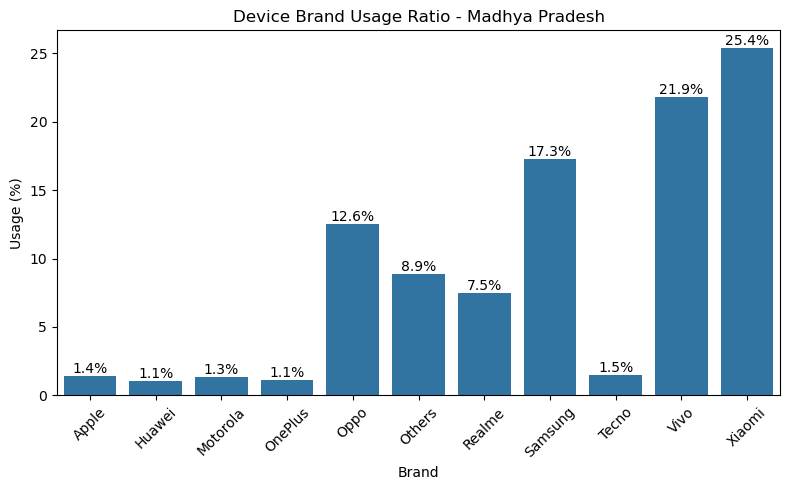

In [58]:
# PLOT A BAR CHART FOR TOP 5 STATES
state_name = 'Madhya Pradesh'
plot_data = merged[merged['State'] == state_name]
plt.figure(figsize=(8,5))
ax=sns.barplot(
    data=plot_data,
    x='Brand',
    y='user_ratio%'
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')     # To add data labels on top of bars in seaborn
plt.title(f'Device Brand Usage Ratio - {state_name}')
plt.xlabel('Brand')
plt.ylabel('Usage (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

INSIGHT--> DEVICE BRAND USAGE RATIO IS HIGHEST FOR XIAOMI BRAND.